# Ortogonalidad entre letras del abecedario

Idea: armar un abecedario de letras de 5×5 con `1` / `-1`, generar todas las combinaciones posibles de 4 letras y ordenarlas por el **producto interno medio** y el **producto interno máximo** entre pares. Esto permite elegir grupos de 4 letras lo más "ortogonales" posible para almacenar en una red de Hopfield.

In [13]:
import string
import itertools

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# from hopfield import Hopfield        # cuando tengamos implementada la red
# from utils import noise_transform    # helper para meterle ruido a un patrón

In [14]:
def create_letter_plot(letter, ax, cmap='Blues'):
    p = sns.heatmap(letter, ax=ax, annot=False, cbar=False, cmap=cmap,
                    square=True, linewidth=2, linecolor='black')
    p.xaxis.set_visible(False)
    p.yaxis.set_visible(False)
    return p


def print_letters_line(letters, cmap='Blues', cmaps=[]):
    fig, ax = plt.subplots(1, len(letters))
    fig.set_dpi(360)
    if len(letters) == 1:
        ax = [ax]
    if not cmaps:
        cmaps = [cmap] * len(letters)
    if len(cmaps) != len(letters):
        raise Exception('cmap list should be the same length as letters')
    for i, subplot in enumerate(ax):
        create_letter_plot(letters[i].reshape(5, 5), ax=subplot, cmap=cmaps[i])
    plt.show()

## Parse Letters

El archivo `letters.txt` tiene 26 letras separadas por `=` (o `=====`). Cada letra son 5 líneas donde `*` representa pixel encendido (`1`) y cualquier otro carácter representa pixel apagado (`-1`). Si una línea es más corta que 5 caracteres, las columnas faltantes quedan en `-1`.

In [15]:
with open('letters.txt') as fp:
    letters = {}
    current = np.ones((5, 5)) * -1
    idx = 0
    for line in fp:
        if not line.strip():
            continue
        if line[0] == '=':
            letters[string.ascii_uppercase[len(letters)]] = current
            current = np.ones((5, 5)) * -1
            idx = 0
        else:
            for i, c in enumerate(line.rstrip('\n')):
                if i >= 5:
                    break
                current[idx][i] = 1 if c == '*' else -1
            idx += 1

print(f'Letras cargadas: {len(letters)}')
print(f'Letras: {list(letters.keys())}')

Letras cargadas: 26
Letras: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


## Visualización del abecedario completo

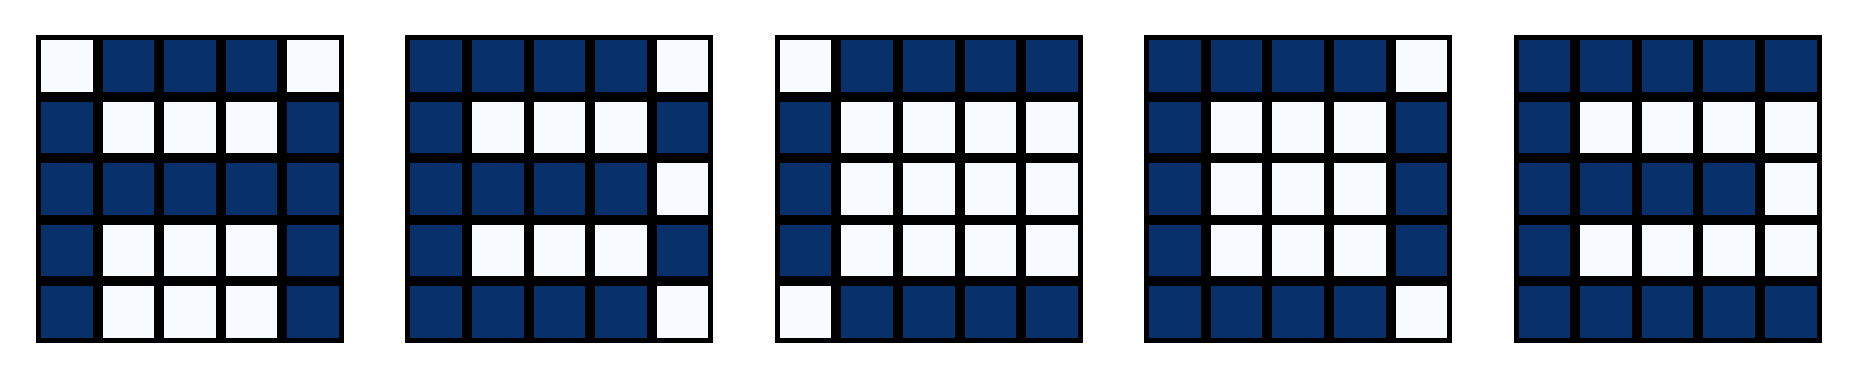

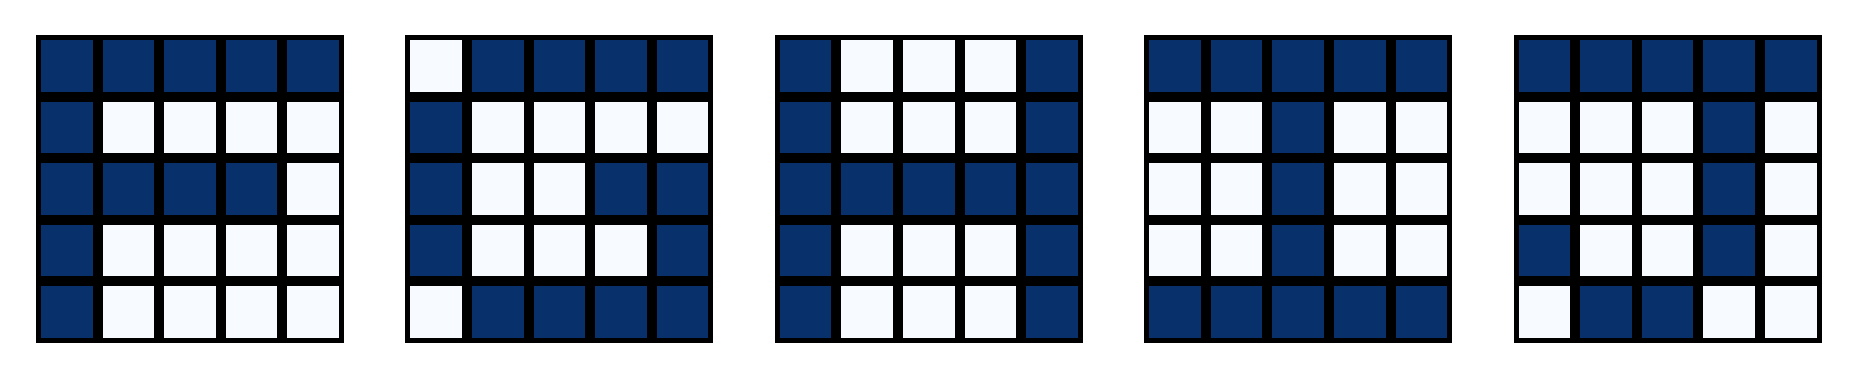

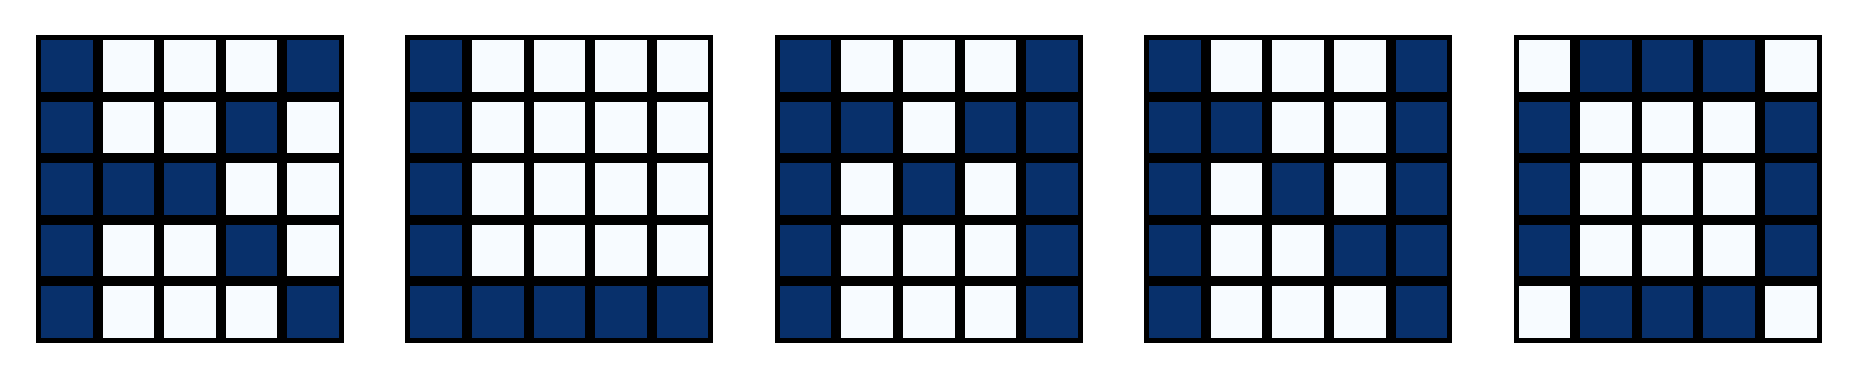

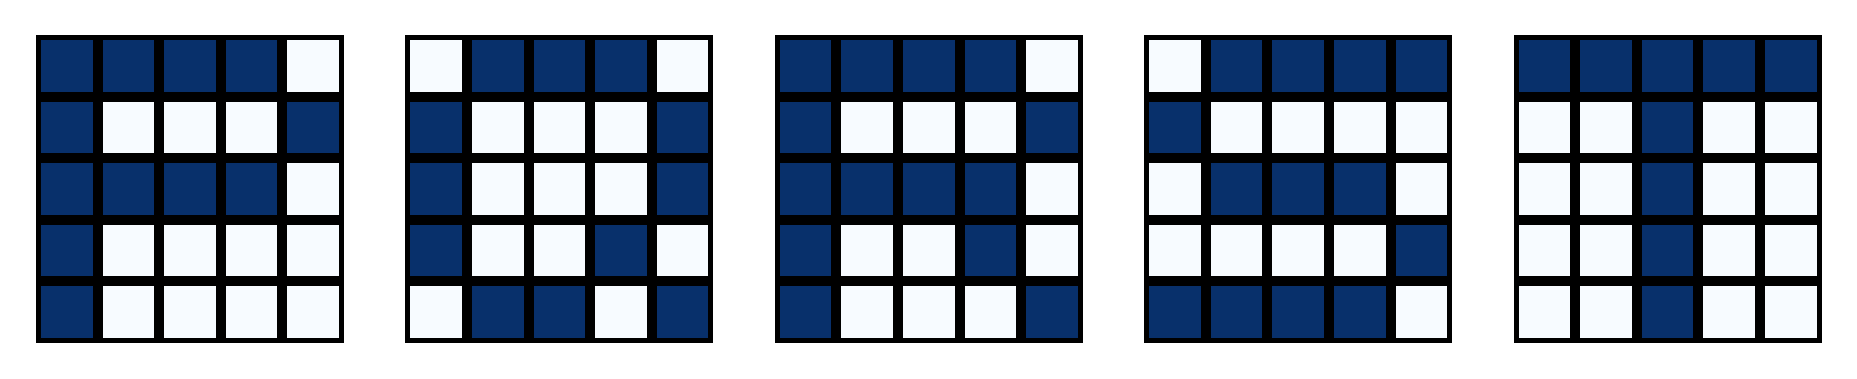

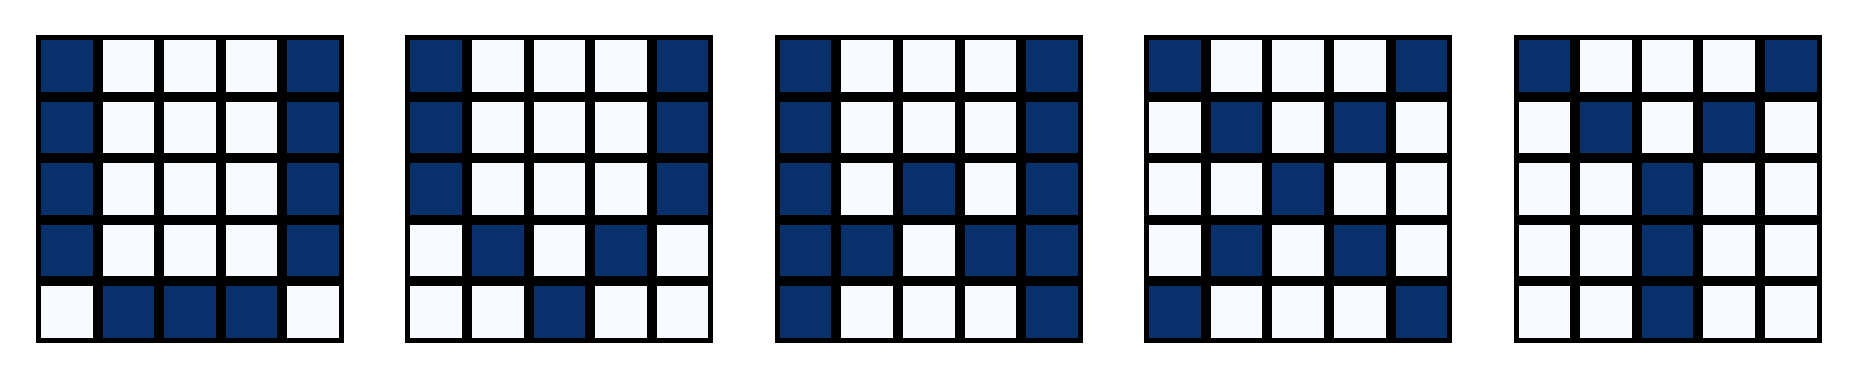

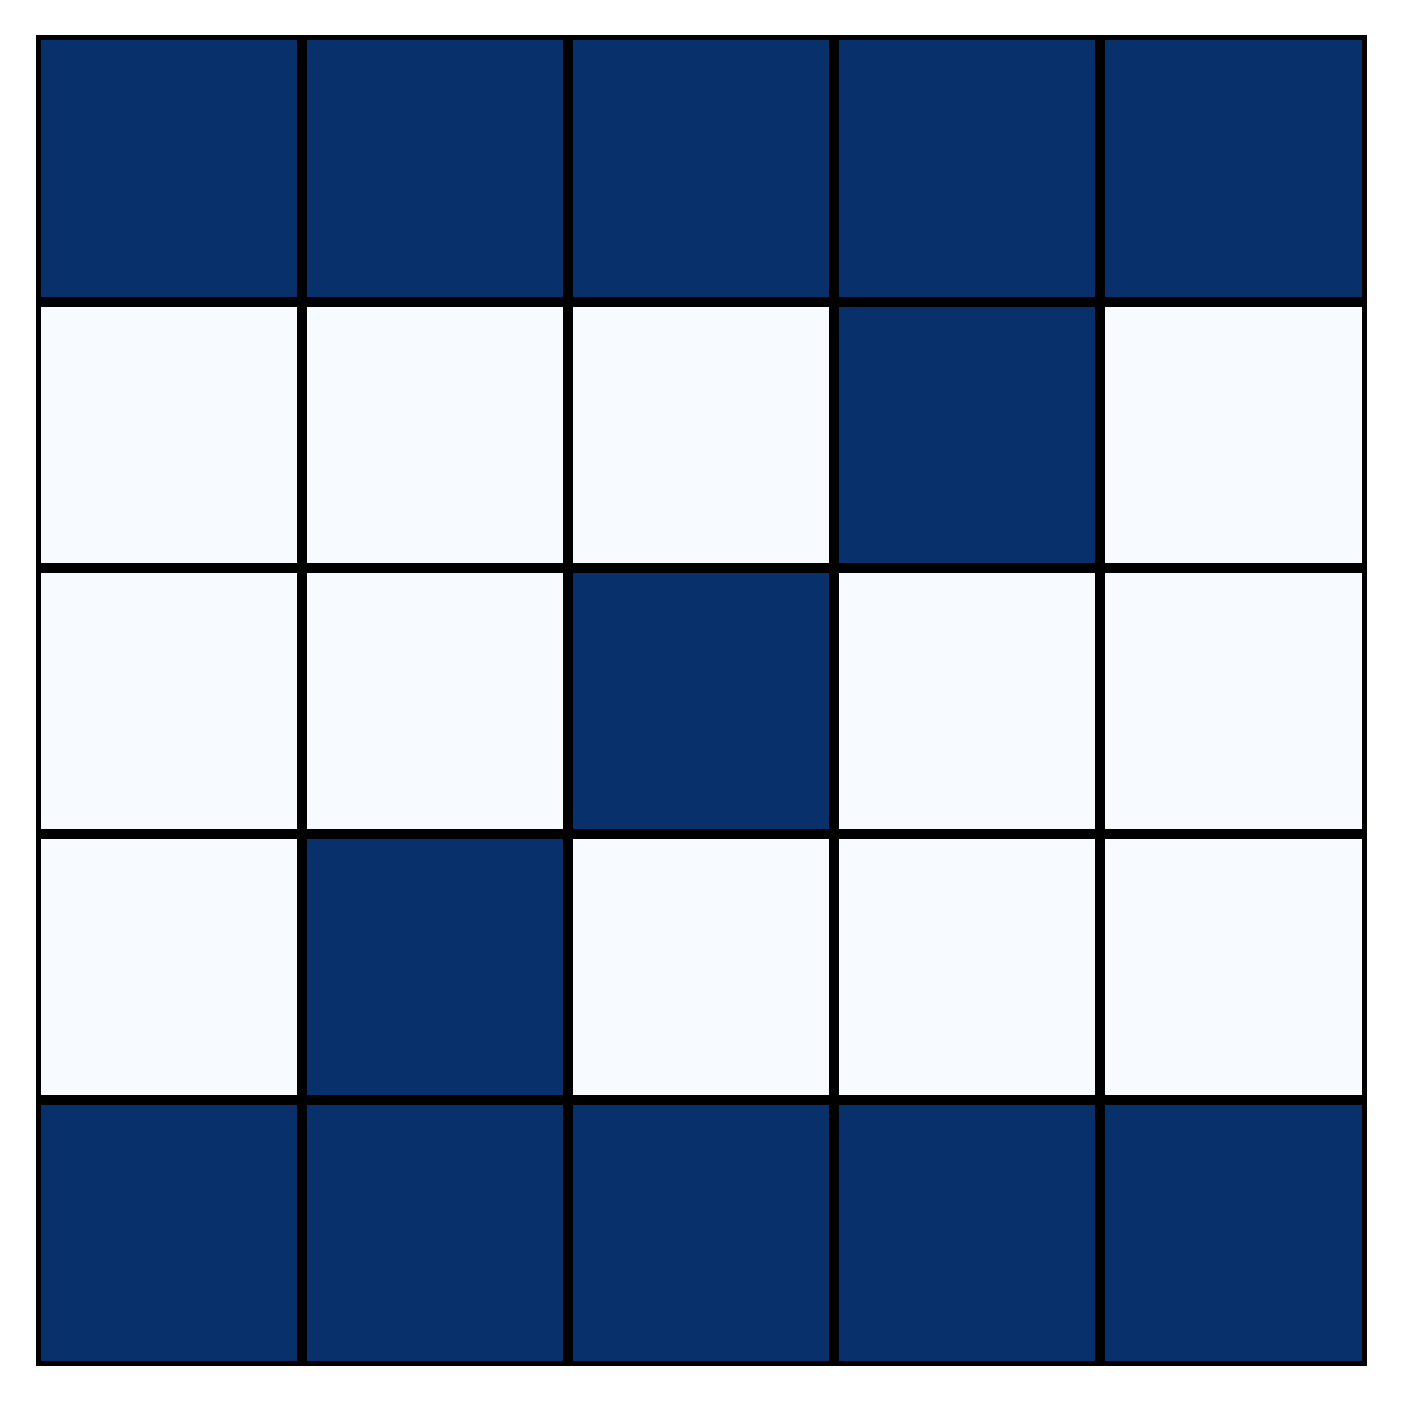

In [4]:
alphabet = list(letters.values())
# Mostramos el abecedario completo en filas de 13 para que entre en pantalla
for chunk_start in range(0, len(alphabet), 5):
    print_letters_line(alphabet[chunk_start:chunk_start + 5])

## Best 4-group combo

Recorremos todas las combinaciones posibles de 4 letras (C(26, 4) = 14.950 combinaciones) y para cada grupo armamos la matriz `K = [v_A; v_B; v_C; v_D]` con los patrones aplanados.

Calculamos `K · K^T`: en la diagonal queda `25` (el producto interno de cada patrón consigo mismo, porque son vectores de ±1 de tamaño 25) y fuera de la diagonal queda el producto interno entre cada par de patrones. La diagonal la ponemos en 0 para que no contamine el promedio.

Para cada grupo guardamos:

- `|<,>| medio`: promedio del valor absoluto de los productos internos entre pares distintos (queremos que sea **chico** → patrones más "ortogonales").
- `|<,>| max`: máximo del valor absoluto de los productos internos, y cuántas veces aparece ese máximo en el grupo. El promedio solo no alcanza porque pierde información: un grupo con un solo par muy parecido puede tener el mismo promedio que un grupo con varios pares medianamente parecidos.

In [16]:
flat_letters = {
    k: m.flatten() for k, m in letters.items()
}

all_groups = itertools.combinations(flat_letters.keys(), r=4)

avg_dot_product = []
max_dot_product = []

for g in all_groups:
    group = np.array([v for k, v in flat_letters.items() if k in g])
    orto_matrix = group.dot(group.T)
    np.fill_diagonal(orto_matrix, 0)
    row, _ = orto_matrix.shape
    avg_dot_product.append((np.abs(orto_matrix).sum() / (orto_matrix.size - row), g))
    max_v = np.abs(orto_matrix).max()
    max_dot_product.append(((max_v, np.count_nonzero(np.abs(orto_matrix) == max_v) / 2), g))

print(f'Combinaciones evaluadas: {len(avg_dot_product)}')

Combinaciones evaluadas: 14950


### Mejores grupos por producto interno medio

Los grupos con el `|<,>| medio` más bajo son los más "ortogonales" en promedio. Estos son los mejores candidatos para almacenar en la red.

In [17]:
df = pd.DataFrame(sorted(avg_dot_product), columns=['|<,>| medio', 'grupo'])
df.head(15).style.format({'|<,>| medio': '{:.2f}'}).hide(axis='index')

"|<,>| medio",grupo
1.00,"('G', 'R', 'T', 'V')"
1.33,"('G', 'P', 'T', 'V')"
1.33,"('O', 'R', 'T', 'V')"
1.67,"('G', 'P', 'V', 'Z')"
1.67,"('G', 'R', 'V', 'Z')"
1.67,"('J', 'L', 'R', 'X')"
1.67,"('L', 'R', 'T', 'X')"
1.67,"('M', 'O', 'R', 'Z')"
1.67,"('O', 'R', 'V', 'Z')"
1.67,"('R', 'T', 'V', 'X')"


### Peores grupos por producto interno medio

In [18]:
df.tail(15).style.format({'|<,>| medio': '{:.2f}'}).hide(axis='index')

"|<,>| medio",grupo
15.67,"('B', 'D', 'O', 'X')"
15.67,"('B', 'E', 'P', 'R')"
15.67,"('D', 'G', 'O', 'Q')"
15.67,"('D', 'G', 'O', 'X')"
15.67,"('H', 'K', 'M', 'N')"
15.67,"('H', 'K', 'N', 'W')"
16.00,"('C', 'D', 'G', 'O')"
16.00,"('C', 'G', 'O', 'Q')"
16.33,"('A', 'B', 'P', 'R')"
16.33,"('B', 'E', 'F', 'P')"


### Mejores grupos por producto interno máximo

El promedio se forma por los números que tiene adentro. Dos grupos pueden tener el mismo promedio pero distinta distribución: uno puede tener un par muy parecido y los demás muy distintos, otro puede tener todos los pares medianamente parecidos. Por eso miramos también el máximo y cuántas veces aparece.

In [19]:
df2 = pd.DataFrame(sorted(max_dot_product), columns=['|<,>| max', 'grupo'])
df2.head(15).style.format({
    '|<,>| max': lambda x: 'max: {:,.0f} | count: {:,.0f}'.format(*x)
}).hide(axis='index')

"|<,>| max",grupo
max: 1 | count: 6,"('G', 'R', 'T', 'V')"
max: 3 | count: 1,"('G', 'P', 'T', 'V')"
max: 3 | count: 1,"('O', 'R', 'T', 'V')"
max: 3 | count: 2,"('G', 'P', 'V', 'Z')"
max: 3 | count: 2,"('G', 'R', 'V', 'Z')"
max: 3 | count: 2,"('J', 'L', 'R', 'X')"
max: 3 | count: 2,"('L', 'R', 'T', 'X')"
max: 3 | count: 2,"('M', 'O', 'R', 'Z')"
max: 3 | count: 2,"('O', 'R', 'V', 'Z')"
max: 3 | count: 3,"('F', 'M', 'O', 'Z')"


### Combinando ambas métricas

Cruzamos las dos tablas para ver, entre los grupos con menor `|<,>| max`, cuál tiene también un buen `|<,>| medio`. Idealmente queremos un grupo con `|<,>| max` chico, `count` chico y `|<,>| medio` chico.

In [20]:
df3 = df2.merge(df)
df3 = df3[['|<,>| max', '|<,>| medio', 'grupo']]
df3.head(15).style.format({
    '|<,>| max': lambda x: 'max: {:,.0f} | count: {:,.0f}'.format(*x),
    '|<,>| medio': '{:.2f}'
}).hide(axis='index')

"|<,>| max","|<,>| medio",grupo
max: 1 | count: 6,1.00,"('G', 'R', 'T', 'V')"
max: 3 | count: 1,1.33,"('G', 'P', 'T', 'V')"
max: 3 | count: 1,1.33,"('O', 'R', 'T', 'V')"
max: 3 | count: 2,1.67,"('G', 'P', 'V', 'Z')"
max: 3 | count: 2,1.67,"('G', 'R', 'V', 'Z')"
max: 3 | count: 2,1.67,"('J', 'L', 'R', 'X')"
max: 3 | count: 2,1.67,"('L', 'R', 'T', 'X')"
max: 3 | count: 2,1.67,"('M', 'O', 'R', 'Z')"
max: 3 | count: 2,1.67,"('O', 'R', 'V', 'Z')"
max: 3 | count: 3,2.00,"('F', 'M', 'O', 'Z')"


## Visualización de un grupo

Mostramos un grupo "bueno" (alto en la tabla de menor producto interno medio) y un grupo "malo" (con producto interno alto) para comparar visualmente. Cuanto más parecidas son las letras entre sí, más alto el producto interno.

Grupo: ['G', 'R', 'T', 'V']
|<G,R>| = 1
|<G,T>| = 1
|<G,V>| = 1
|<R,T>| = 1
|<R,V>| = 1
|<T,V>| = 1


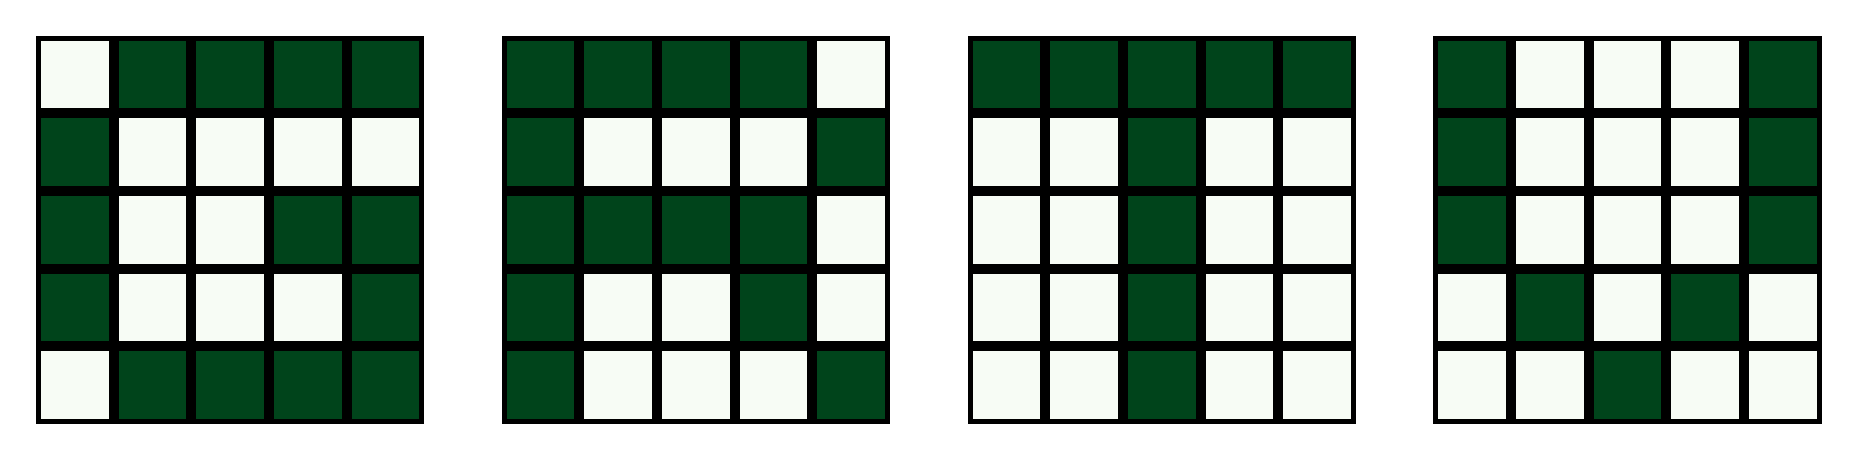

In [22]:
def show_group(patterns, title=None):
    flat_group = np.array([letters[k].flatten() for k in patterns])
    print(f'Grupo: {patterns}')
    for k1, v1 in zip(patterns, flat_group):
        for k2, v2 in zip(patterns, flat_group):
            if k1 < k2:
                print(f'|<{k1},{k2}>| = {int(abs(v1.dot(v2)))}')
    print_letters_line(flat_group, cmap='Greens')

# Mejor grupo según producto interno medio
best_group = df.iloc[0]['grupo']
show_group(list(best_group))

Grupo: ['H', 'M', 'N', 'W']
|<H,M>| = 17
|<H,N>| = 17
|<H,W>| = 17
|<M,N>| = 21
|<M,W>| = 17
|<N,W>| = 21


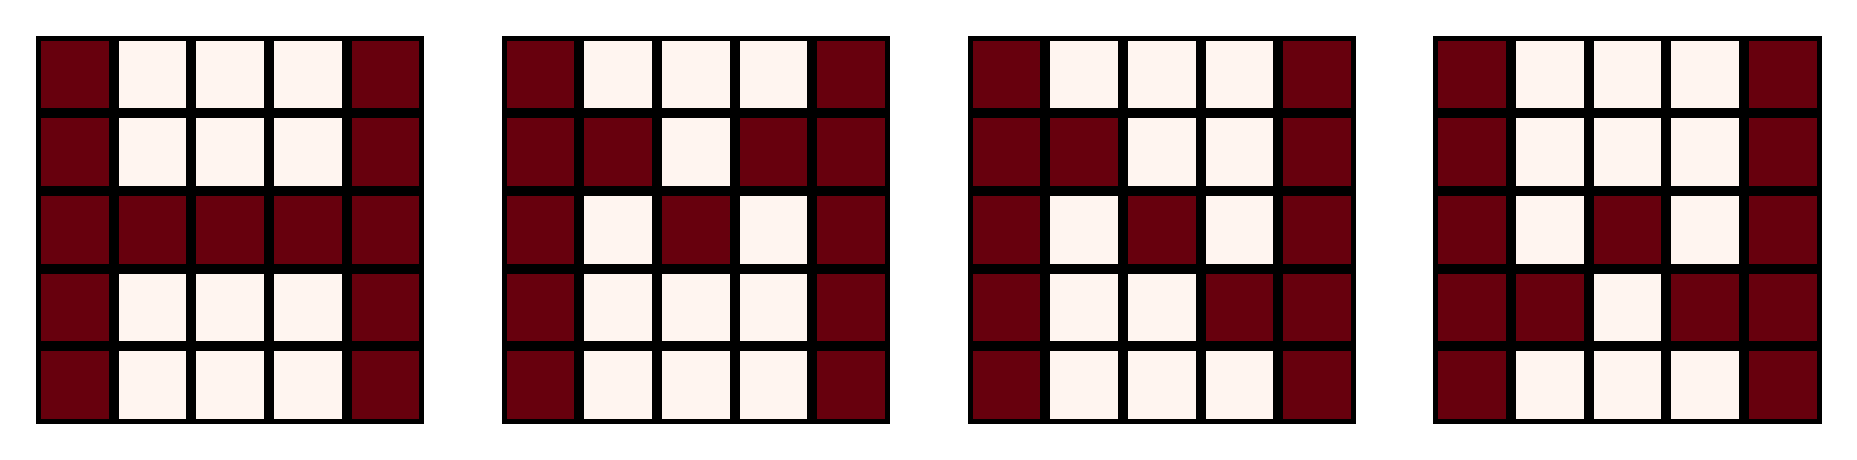

In [11]:
# Peor grupo según producto interno medio
worst_group = df.iloc[-1]['grupo']
show_group(list(worst_group))

Grupo: ['A', 'F', 'P', 'R']
|<A,F>| = 13
|<A,P>| = 17
|<A,R>| = 17
|<F,P>| = 21
|<F,R>| = 17
|<P,R>| = 21


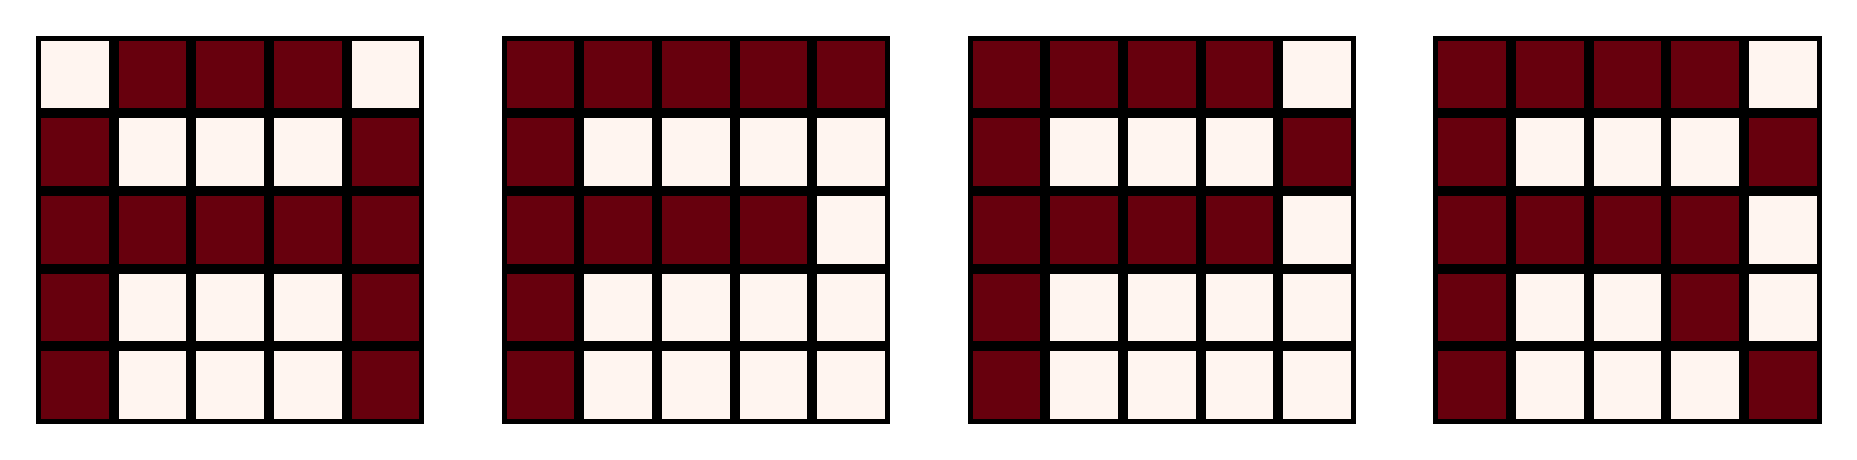

In [12]:
# Grupo arbitrario para comparar (ejemplo del prof: ['A','F','P','R'] suele ser malo)
show_group(['A', 'F', 'P', 'R'])